# <center> 八 LangGraph 中 Human-in-the-loop 应用实战

&emsp;&emsp;我们课程截至到目前，**我们现在能够实现的最复杂的一种`AI Agent`逻辑是：具备多外部工具支持的完全自主循环代理结构，同时具备多轮对话的上下文记忆能力**。而具备这种能力的系统其实已经足够有效地应对大部分`AI`应用场景的需求，并且已经完全涵盖了`LangGraph`底层构建生产级别`Agent`的所必须掌握的知识点 。最后，我们要进行补充的是：**这种完全自主循环代理构建起来的应用，在现实落地场景中，会衍生出什么迫切的需求？**

&emsp;&emsp;一个有趣且现实的情况是：我们希望`AI Agent`能够帮助我们自主处理各种任务，但当它现在有能力做到时，我们又开始担心它可能做出不当的决策，尤其是涉及到高风险操作时。比如，`Agent` 可能会不小心删除生产环境中的数据库，或是转移账户中的余额等敏感数据。这些操作是无法容忍的。因此，在自主代理类架构下衍生出的非常明确的一类需求是：**能否在保持`Agent`自主决策的基础上，对某些可以预见或计划的关键节点引入人工干预，暂时中止其自我决策过程，转而由人工介入进行审批和确认，再让其继续执行后续任务**？比如以下场景：

- **删除数据库操作**：当`Agent`决定删除数据库时，可以先中止操作，要求人工确认是否继续执行。经过人工确认后，`Agent`才继续删除数据库并执行后续操作。
- **机票改签操作**：当`Agent`决定更改机票时，系统会向用户发出通知，等待用户确认是否同意改签，用户点击确认后，`Agent`才会继续执行改签操作。
- .......

&emsp;&emsp;通过这种方式，既能保持`Agent`的自主性，又能避免出现意外或不可控的风险，实现人机协作的平衡。而**实现这种功能的技术，在`Agent`技术领域会被普遍称之为`Human-in-the-loop`（HIL）。**

<div align=center><img src="../pic/lesson05/2.png" width=60%></div>

## 1. LangGraph中的HIL

&emsp;&emsp;`LangGraph`底层是通过图结构来进行构建，并由状态做消息的传递，那么对于这样的结构来说，如果我们想在这样的架构中加入人工的介入流程，能操作的大致思路应该是：通过`Router Agent`去做判断，如果生成的响应触发了某种条件，就在原本要正常进入的节点之前先停止，等待人工的确认，再决定要不要执行，或者执行什么逻辑。在这个过程中，有几种常见的用户交互模式，分别是：

- **批准（Approval）**：在代理的执行过程中，人工暂停代理的自主工作流，向用户展示当前的状态，并批准或者不批准执行该操作。
- **编辑（Editing）**：在需要的时候，人工可以暂停代理，向用户展示当前的状态，并允许用户对代理的状态进行编辑。
- **输入（Input）**：专门设计一个图节点来收集用户的输入，并将这些输入直接用于更新代理的状态。

&emsp;&emsp;在`LangGraph`的设计思路下 **`HIL`通过战略性地放置断点（`breakpoint`）来实现的。这些断点会在关键点停止图的执行。在暂停期间，`Agent`将等待用户输入，利用这段时间收集响应，将它们集成到图状态中，并顺利继续进行，从而实现用户和代理之间的协作和交互式体验** 这个交互过程在`LangGraph`框架下的具体实现思路如下图所示：

> 图片来源：https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/breakpoints/

<div align=center><img src="../pic/lesson08/1.png" width=70%></div>

&emsp;&emsp;`LangGraph`能够**在中断后继续运行的核心在于我们之前介绍的`checkpointer`组件**。这个组件能够在一个独立的线程中保存图中每个节点的状态。由于这些信息被持久化保存（包括将内存用作持久存储），我们就可以随时提取并修改图产生的数据。更改完成后，再将这些数据重新传回到图中以继续运行流程。这一机制是`LangGraph`已成功实现的功能。**由此可见 `Human-in-the-loop (HIL)` 并不是一个全新的组件，而是基于`LangGraph`底层的构建组件延展出来的一种实现方法。那这里我们就需要清楚两个概念，其一是用于中断两个本应顺序执行节点的操作，在`LangGraph`中称其为`breakpoint`（断点），其二是`breakpoint`是构建在`checkpointer`之上的。**

&emsp;&emsp;因此，当我们需要在定义的图结构中加入人机交互，这个图必须具备的两个核心参数正如`compile()`方法中的源码所示：

> LangGraph Graph Compile ：https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.state.StateGraph.compile

```python
def compile(
    self,
    checkpointer: Checkpointer = None,    
    *,
    store: Optional[BaseStore] = None,
    interrupt_before: Optional[Union[All, list[str]]] = None,
    interrupt_after: Optional[Union[All, list[str]]] = None,
    debug: bool = False,
) -> "CompiledStateGraph":
```

&emsp;&emsp;**其中，`checkpointer`参数可以接收任意类型的`checkpointer`，用来保存图的状态。而`interrupt_before`和`interrupt_after`参数，接收图中某个节点的名称，将其作为`breakpoint`，起到的作用是在该节点之前/之后中断图的继续运行**。我们来看一个具体的应用案例。

# 2. 标准图结构中如何添加断点

&emsp;&emsp;如下代码实现的业务场景是一个自动化的人机交互流程，用于执行内容删除这种高度敏感性的操作。我们定义两个主要的功能节点：`call_model`和`execute_users`。`call_model`节点处理大模型的调用和响应，如果用户输入包含“删除”的内容，则会触发需要人工审批的流程。`execute_users`节点根据人工审核的结果来决定最终的响应内容。如下代码所示：

In [1]:
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

# DeepSeek API 配置
key = "your-deepseek-api-key"
base_url = "https://api.deepseek.com/v1"

llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)


def display_graph(graph, xray=False):
    """Render LangGraph structure; fall back to Mermaid text if mermaid.ink is unreachable."""
    g = graph.get_graph(xray=xray)
    try:
        display(Image(g.draw_mermaid_png(max_retries=3, retry_delay=2.0)))
    except ValueError:
        print(g.draw_mermaid())


In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)


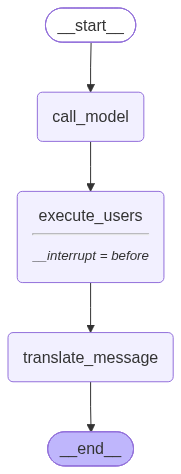

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display
from langchain_core.tools import tool
from langgraph.graph import MessagesState, START
from langgraph.prebuilt import ToolNode
from langgraph.graph import END, StateGraph
import json
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage

# 定义状态模式
class State(TypedDict):
    user_input: str
    model_response: str
    user_approval: str

# 定义用于大模型交互的节点
def call_model(state):
    messages = state["user_input"]
    if '删除' in state["user_input"]:
        state["user_approval"] = f"用户输入的指令是:{state['user_input']}, 请人工确认是否执行！"
    else:
        response = llm.invoke(messages)
        state["user_approval"] = "直接运行！"
        state["model_response"] = response
    return state

# 定义人工介入的breakpoint内部的执行逻辑
def execute_users(state):
    if state["user_approval"] == "是":
        response = "您的删除请求已经获得管理员的批准并成功执行。如果您有其他问题或需要进一步的帮助，请随时联系我们。"
        return {"model_response":AIMessage(response)}
    elif state["user_approval"] == "否":
        response = "对不起，您当前的请求是高风险操作，管理员不允许执行！"
        return {"model_response":AIMessage(response)}    
    else:
        return state

# 定义翻译节点
def translate_message(state: State):
    system_prompt = """
    Please translate the received text in any language into English as output
    """
    messages = state['model_response']
    messages = [SystemMessage(content=system_prompt)] + [HumanMessage(content=messages.content)]
    response = llm.invoke(messages)
    return {"model_response": response}

# 构建状态图
builder = StateGraph(State)

# 向图中添加节点
builder.add_node("call_model", call_model)
builder.add_node("execute_users", execute_users)
builder.add_node("translate_message", translate_message)

# 构建边
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "execute_users")
builder.add_edge("execute_users", "translate_message")
builder.add_edge("translate_message", END)

# 设置 checkpointer，使用内存存储
memory = MemorySaver()

# 在编译图的时候，添加短期记忆，并使用interrupt_before参数 设置 在 execute_users 节点之前中止图的运行，等待人工审核
graph = builder.compile(checkpointer=memory, interrupt_before=["execute_users"])

# 生成可视化图像结构
display_graph(graph)


&emsp;&emsp;在添加了`breakpoint` （断点）后的图结构中，它的运行逻辑将变成：只要到达被设置为`breakpoint`的节点时，图就会中止运行。这里我们进行一个实际的调用测试来理解这个过程，代码如下所示：

In [4]:
# 创建一个线程
config = {"configurable": {"thread_id": "2"}}

# 运行图，直至到断点的节点
async for chunk in graph.astream({"user_input": "我将在数据库中删除 id 为 xigualaoshi 的所有信息"}, config,  stream_mode="values"):
    print(chunk)

{'user_input': '我将在数据库中删除 id 为 xigualaoshi 的所有信息'}
{'user_input': '我将在数据库中删除 id 为 xigualaoshi 的所有信息', 'user_approval': '用户输入的指令是:我将在数据库中删除 id 为 xigualaoshi 的所有信息, 请人工确认是否执行！'}


&emsp;&emsp;通过输出结果，我们可以观察到在执行到`execute_users`节点之前就暂停了，它将等待人工介入以决定是否继续执行。这就是`breakpointer`（断点）的关键作用。在这个阶段，我们就可以审查并调整图的状态，而关键的处理逻辑是：要修改或确认全局状态模式中`user_approval`字段的值，从而指导`execute_users`节点的行为。

&emsp;&emsp;通过`get_state()`方法，可以查看到截至断点`breakpoint`前，图的运行过程中都产生了哪些状态信息：

In [5]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'user_input': '我将在数据库中删除 id 为 xigualaoshi 的所有信息', 'user_approval': '用户输入的指令是:我将在数据库中删除 id 为 xigualaoshi 的所有信息, 请人工确认是否执行！'}, next=('execute_users',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f194d1c-ee6f-6122-8001-2d1586d958a1'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-10T15:40:26.551305+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f194d1c-ee6a-6172-8000-ad841f465dfd'}}, tasks=(PregelTask(id='3d201f19-c1c9-7bf4-eae0-7bae6f252597', name='execute_users', path=('__pregel_pull', 'execute_users'), error=None, interrupts=(), state=None, result=None),), interrupts=())

&emsp;&emsp;我们先来看如何在图中止运行后，在图状态中添加用户的决策。

&emsp;&emsp;为实现这一点，我们可以手动设置`snapshot.values['user_approval']`为'是'，用以说明在即将执行的`execute_users`节点，人工审批的状态被手动设定为同意。接下来，使用`graph.update_state(config, snapshot.values)`来更新状态图中的状态。这个调用将状态图中的当前状态更新为包含了新的`user_approval`值的`snapshot.values`。

In [6]:
snapshot.values['user_approval']='是'
graph.update_state(config, snapshot.values)

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f194d23-90a8-6474-8002-701376bb0526'}}

&emsp;&emsp;修改完状态后，如果想让图基于`breakpoint`继续执行后续的操作，则只需要在`astream`方法中将`input`参数设置为 `None`, 则会让图形从上次中断的地方继续。如下代码所示：

In [8]:
async for chunk in graph.astream(None, config, stream_mode="values"):
    print(chunk)

{'user_input': '我将在数据库中删除 id 为 xigualaoshi 的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved by the administrator and successfully executed. If you have any other questions or need further assistance, please feel free to contact us.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 44, 'total_tokens': 75, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 44}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '79674be5-a44e-44cf-ba78-1b006c0e0376', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fec58-df8f-7150-b7c7-50c243e9359a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 31, 'total_tokens': 75, 'input_token_details': {'cache_read

&emsp;&emsp;再次运行一轮新的对话：

In [9]:
# 运行图，直至到断点的节点
async for chunk in graph.astream({"user_input": "我将在数据库中删除 id 为 xigualaoshi222 的所有信息"}, config,  stream_mode="values"):
    print(chunk)

{'user_input': '我将在数据库中删除 id 为 xigualaoshi222 的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved by the administrator and successfully executed. If you have any other questions or need further assistance, please feel free to contact us.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 44, 'total_tokens': 75, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 44}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '79674be5-a44e-44cf-ba78-1b006c0e0376', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fec58-df8f-7150-b7c7-50c243e9359a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 31, 'total_tokens': 75, 'input_token_details': {'cache_r

In [10]:
snapshot = graph.get_state(config)

In [11]:
snapshot.values['user_approval']='否'
graph.update_state(config, snapshot.values)

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f194d4c-f943-60fa-8008-fb84faf6a182'}}

In [12]:
async for chunk in graph.astream(None, config, stream_mode="values"):
    print(chunk)

{'user_input': '我将在数据库中删除 id 为 xigualaoshi222 的所有信息', 'model_response': AIMessage(content='Your deletion request has been approved by the administrator and successfully executed. If you have any other questions or need further assistance, please feel free to contact us.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 44, 'total_tokens': 75, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 44}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '79674be5-a44e-44cf-ba78-1b006c0e0376', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fec58-df8f-7150-b7c7-50c243e9359a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 31, 'total_tokens': 75, 'input_token_details': {'cache_r

&emsp;&emsp;以上是两种触发`删除`的高危风险审核的逻辑，而如果`Agent`接收的是普通的问答交互，不涉及高危险操作指令时，则可以直接将`input`参数设置为`None`，运行断点之后的图节点逻辑。如下代码所示：

In [13]:
# 运行图，直至到断点的节点
async for chunk in graph.astream({"user_input": "你好，请你介绍一下你自己"}, config,  stream_mode="values"):
    pass

async for chunk in graph.astream(None, config, stream_mode="values"):
    print(chunk)

{'user_input': '你好，请你介绍一下你自己', 'model_response': AIMessage(content='你好呀！很高兴认识你！😊\n\n我是**DeepSeek**，由深度求索公司创造的AI助手。让我给你介绍一下我的“特长”：\n\n✨ **我的核心能力**：\n- **纯文本对话**：我擅长文字交流，可以回答各种问题、帮你分析问题、创作内容等\n- **超长上下文**：我有1M的上下文窗口，可以一次性处理像《三体》三部曲那么大体量的书籍\n- **文件处理**：支持上传图片、PDF、Word、Excel、PPT等文件，我能读取其中的文字信息帮你处理\n- **联网搜索**：需要最新信息时，你可以手动开启联网功能（在Web/App端点击按钮）\n\n🎯 **我的特点**：\n- **完全免费**：没错，不收费！你可以放心使用\n- **多平台支持**：有网页版和App（可在官方应用商店下载），App还支持语音输入\n- **知识更新**：我的知识截止到2025年5月\n\n💡 **我能帮你做什么**：\n- 解答疑问、提供建议\n- 写作、翻译、编程\n- 分析文档、总结内容\n- 头脑风暴、创意构思\n- 学习辅导、知识科普\n\n有什么我可以帮你的吗？尽管问，我会热情地为你解答！🌟', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 275, 'prompt_tokens': 9, 'total_tokens': 284, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 9}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_2026

&emsp;&emsp;等待人工输入是一种常见的 HIL 交互模式，它能够允许我们构建的代理向用户提出需要确认的问题，并等待确认输入后再继续。其中具体要执行的关键步骤是：
1. 需要在图编译时通过`interrupt_before`或者`interrupt_after`设置断点。
2. 需要在图编译时设置一个`checkpointer` 来保存图的状态。
3. 需要使用 `.update_state` 来更新图的状态，其中要包含我们得到的人工响应。
4. 恢复图的执行，等待图运行结束，输出最终的响应结果。

&emsp;&emsp;我们可以把上述过程构建成一个具备多轮对话形式的人机交互流程，如下代码所示：

In [14]:
# 创建一个函数来封装对话逻辑
def run_dialogue(graph, config, all_chunks=[]):
    while True:
        # 接收用户输入
        user_input = input("请输入您的消息（输入'退出'结束对话）：")
        if user_input.lower() == '退出':
            break
        
        # 运行图，直至到断点的节点
        for chunk in graph.stream({"user_input": user_input}, config, stream_mode="values"):
            all_chunks.append(chunk)
        
        # 处理可能的审批请求
        last_chunk = all_chunks[-1]
        if last_chunk["user_approval"] ==  f"用户输入的指令是:{last_chunk['user_input']}, 请人工确认是否执行！":
            user_approval = input(f"当前用户的输入是：{last_chunk['user_input']}, 请人工确认是否执行！请回复 是/否。")
            graph.update_state(config, {"user_approval": user_approval})

        # 继续执行图
        for chunk in graph.stream(None, config, stream_mode="values"):
            all_chunks.append(chunk)
        
        # 显示最终模型的响应
        print("人工智能助理：", all_chunks[-1]["model_response"].content)

&emsp;&emsp;进行调用测试：

In [15]:
# 初始化配置和状态存储
config = {"configurable": {"thread_id": "3"}}

# 使用该函数运行对话
run_dialogue(graph, config)

请输入您的消息（输入'退出'结束对话）： 你好


人工智能助理： Hello there! Nice to meet you! 😊

I'm DeepSeek, your AI assistant. Whether you want to chat, ask questions, seek help, or need creative inspiration, I'm always at your service!

Is there anything I can help you with today? Or do you just want to have a casual chat? I'm more than happy either way! ✨


请输入您的消息（输入'退出'结束对话）： 删除这段对话
当前用户的输入是：删除这段对话, 请人工确认是否执行！请回复 是/否。 是


人工智能助理： Your deletion request has been approved by the administrator and successfully executed. If you have any other questions or need further assistance, please feel free to contact us.


请输入您的消息（输入'退出'结束对话）： 退出


&emsp;&emsp;如上实现的功能所示，**在图中的特定位置添加断点是启用人机协同的一种方法。在这种情况下，开发人员只要知道工作流中的哪个位置需要人工输入，只需在该特定图形节点之前或之后放置一个断点即可。`LangGraph`的`breakpoint`和`HIL`功能提供了比较完善的实现机制来做交互式的图执行，允许用户输入来指导或中断流程。**在这个案例中，我们展示的**人机交互策略特别适用于有明确工作流的业务场景**。开发人员可以根据业务逻辑精确地确定哪些环节可能涉及高风险操作，并通过人工决策介入来提升Agent应用程序的稳定性和可靠性。

&emsp;&emsp;接下来我们可以更近一步，看一下在具备工具调用的`Agent`架构中如何去做断点的人工交互逻辑，这包含`Tool Calling Agent` 和 `ReAct` 两种模式。

## 3. 复杂代理架构中如何添加动态断点

<div align=center><img src="../pic/lesson05/2.png" width=60%></div>

&emsp;&emsp;上面案例中实现的人机交互模式，我们可以在不同的用户输入决策下完全自定义具体需要执行的操作逻辑。而这样的交互过程，我们可以手动实现来理解这个中间过程，当然也可以在`LangGraph`框架的封装下，借助`Router Agent`的机制从节点内部来进行动态管理，尤其是在涉及工具调用的`ReAct`框架下，其特征会更明显，且可以更加清晰的帮助我们理解`breakpoint`在图执行过程中的内部逻辑。其基本过程如下图所示：

<div align=center><img src="../pic/lesson08/2.png" width=70%></div>

&emsp;&emsp;首先来考虑这样一个场景：对于`Tool Calling Agent`架构实现的应用程序，如果我们希望在执行任意一个工具之前，都需要由人工进行审核的话，那么这个过程就可以非常简单的通过如下代码来进行实现。这里我们先准备两个外部工具，一个用于实时检索互联网信息，一个用于检索实时天气。

In [16]:
from langchain_core.tools import tool
from pydantic import BaseModel, Field
import requests
import json
import time
from langgraph.prebuilt import ToolNode

WEATHERAPI_KEY = "02d81e92a8664fb7a8a81039260908"
WEATHERAPI_CURRENT_URL = "https://api.weatherapi.com/v1/current.json"
WEATHERAPI_MAX_RETRIES = 3


def _condition_to_main(code: int) -> str:
    if code == 1000:
        return "Clear"
    if code in (1003, 1006, 1009):
        return "Clouds"
    if code in (1030, 1135, 1147):
        return "Mist"
    if code in (1087, 1273, 1276, 1279, 1282):
        return "Thunderstorm"
    if code in (1066, 1114, 1117, 1210, 1213, 1216, 1219, 1222, 1225, 1237, 1255, 1258):
        return "Snow"
    if code >= 1063:
        return "Rain"
    return "Unknown"


def _fetch_weatherapi_current(city_name: str) -> dict:
    last_error = None
    for attempt in range(WEATHERAPI_MAX_RETRIES):
        try:
            response = requests.get(
                WEATHERAPI_CURRENT_URL,
                params={"key": WEATHERAPI_KEY, "q": city_name, "lang": "zh"},
                timeout=30,
            )
            response.raise_for_status()
            return response.json()
        except requests.RequestException as exc:
            last_error = exc
            if attempt < WEATHERAPI_MAX_RETRIES - 1:
                time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(
        f"无法连接 WeatherAPI（城市: {city_name}）。"
        f" 原始错误: {last_error}"
    ) from last_error


def _normalize_weather_payload(payload: dict, query_name: str) -> dict:
    location = payload["location"]
    current = payload["current"]
    condition = current["condition"]
    lat, lon = location["lat"], location["lon"]
    temp = current["temp_c"]
    city_id = int(abs(round(lat * 100)) * 1_000_000 + abs(round(lon * 100)))
    vis_km = current.get("vis_km")
    visibility = int(vis_km * 1000) if vis_km is not None else None
    return {
        "coord": {"lon": lon, "lat": lat},
        "weather": [{
            "id": condition["code"],
            "main": _condition_to_main(condition["code"]),
            "description": condition["text"],
            "icon": condition.get("icon", ""),
        }],
        "main": {
            "temp": temp,
            "feels_like": current.get("feelslike_c", temp),
            "temp_min": temp,
            "temp_max": temp,
            "pressure": current.get("pressure_mb"),
            "humidity": current.get("humidity"),
        },
        "visibility": visibility,
        "wind": {"speed": round(current.get("wind_kph", 0) / 3.6, 2), "deg": current.get("wind_degree")},
        "clouds": {"all": current.get("cloud", 0)},
        "dt": current.get("last_updated_epoch"),
        "id": city_id,
        "name": location.get("name", query_name),
        "cod": 200,
    }


class WeatherLoc(BaseModel):
    location: str = Field(description="The location name of the city")


class SearchQuery(BaseModel):
    query: str = Field(description="Questions for networking queries")


@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """Get real-time Internet information"""
    url = "https://google.serper.dev/search"
    payload = json.dumps({"q": query, "num": 1})
    headers = {
        "X-API-KEY": "09b88d55900377e05b0aa283b7cefa97ca73a439",
        "Content-Type": "application/json",
    }
    response = requests.post(url, headers=headers, data=payload)
    data = json.loads(response.text)
    if "organic" in data:
        return json.dumps(data["organic"], ensure_ascii=False)
    return json.dumps({"error": "No organic results found"}, ensure_ascii=False)


@tool(args_schema=WeatherLoc)
def get_weather(location):
    """Query current weather from WeatherAPI.com."""
    try:
        payload = _fetch_weatherapi_current(location)
        data = _normalize_weather_payload(payload, location)
        return json.dumps(data, ensure_ascii=False)
    except Exception as exc:
        return json.dumps({"error": f"Weather API request failed for {location}: {exc}"}, ensure_ascii=False)


&emsp;&emsp;使用`ToolNode`组件将普通函数处理成实际可执行的对象。

In [17]:
get_weather.invoke({"location": "Beijing"})


'{"coord": {"lon": 116.3883, "lat": 39.9289}, "weather": [{"id": 1036, "main": "Unknown", "description": "烟霾", "icon": "//cdn.weatherapi.com/weather/64x64/day/149.png"}], "main": {"temp": 27.7, "feels_like": 29.1, "temp_min": 27.7, "temp_max": 27.7, "pressure": 1008.0, "humidity": 61}, "visibility": 10000, "wind": {"speed": 1.5, "deg": 59}, "clouds": {"all": 16}, "dt": 1786410900, "id": 3993011639, "name": "Beijing", "cod": 200}'

In [18]:
fetch_real_time_info.invoke({"query": "小米汽车"})


'[{"title": "小米汽车", "link": "https://www.xiaomiev.com/", "snippet": "新一代小米SU7; 小米YU7; 小米SU7 Ultra; 定制服务; 车型对比. 小米澎程N90; 小米澎程N70. 核心技术. 小米汽车核心技术. 电子电气架构; 超级电机; 高压平台 ...", "sitelinks": [{"title": "YU7", "link": "https://www.xiaomiev.com/yu7", "snippet": "全系碳化硅高压平台，Xiaomi YU7 Max 峰值电压更高达897V，可以 ..."}, {"title": "新一代SU7", "link": "https://www.xiaomiev.com/su7", "snippet": "电机是新能源汽车的心脏，小米超级电机V6s Plus采用分段磁钢和电 ..."}, {"title": "SU7 Ultra", "link": "https://www.xiaomiev.com/ultra", "snippet": "巅峰动力性能. 超级三电机四驱，1548PS 惊人马力！赛道级高功 ..."}, {"title": "小米澎湃智能座舱", "link": "https://www.xiaomiev.com/smartcabin", "snippet": "采用3D 动态环境渲染架构，匹配车辆内外颜色，线性切换天空效果及 ..."}, {"title": "参数配置表", "link": "https://www.xiaomiev.com/car-config", "snippet": "参数配置表 · 先进的移动智能空间 · 智能座舱系统 · 智能座舱芯片 ..."}], "position": 1}]'

In [19]:
tools = [get_weather, fetch_real_time_info]

tool_node = ToolNode(tools, handle_tool_errors=True)


&emsp;&emsp;定义大模型实例，这里使用`DeepSeek` 模型进行演示。


In [20]:
import getpass
import os
import json
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import MessagesState, START

from langgraph.graph import END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

llm = ChatOpenAI(model="deepseek-chat", api_key=key,base_url=base_url,temperature=0,)

llm = llm.bind_tools(tools)


&emsp;&emsp;定义一个`Router Function`，用来根据大模型的实时响应判断是执行外部函数调用还是直接输出最终的响应。

In [21]:
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    # 如果没有 工具调用，则输出至最终节点
    if not last_message.tool_calls:
        return "end"
    # 如果还有子任务需要继续执行工具调用的话，则继续等待执行
    else:
        return "continue"

&emsp;&emsp;用于大模型交互的节点函数，其功能是接收用户的响应，使用`DeepSeek `模型生成具体的响应文本。


In [22]:
def call_model(state):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

&emsp;&emsp;然后通过`LangGraph`基本构建图的方法，依次定义状态图 -> 向图中添加节点 - > 添加节点之间的边。

In [23]:
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("action", tool_node)


workflow.add_edge(START, "agent")

# 添加条件边 
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "action",
        "end": END,
    },
)

workflow.add_edge("action", "agent")

&emsp;&emsp;最后，如果想要在执行任意工具前都由人工介入进行确认，只需要在编译图的时候，在调用 `action` 节点之前添加一个`breakpoint`（断点）。如下所示：

In [24]:
memory = MemorySaver()

graph = workflow.compile(checkpointer=memory, interrupt_before=["action"])

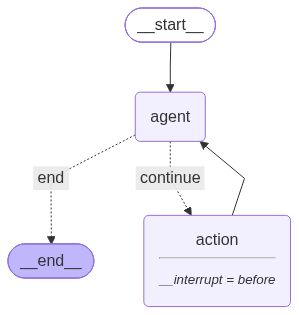

In [25]:
# 生成可视化图像结构
display_graph(graph)


&emsp;&emsp;编译后，则可以开始与基于该图构建出来的 `Agent` 进行对话交互，如下代码所示：

In [26]:
config = {"configurable": {"thread_id": "4"}}

for chunk in graph.stream({"messages": "请帮我查一下北京的天气"}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

请帮我查一下北京的天气
================================== Ai Message ==================================

我来帮您查询北京的天气情况。
Tool Calls:
  get_weather (call_00_g3rWsQ54tOP4CaymUA6m4803)
 Call ID: call_00_g3rWsQ54tOP4CaymUA6m4803
  Args:
    location: 北京


&emsp;&emsp;从输出可以看到，与前几节课我们实践的执行过程不同，在添加了断点后，已经自动在需要执行工具操作前中断了执行。这里的处理逻辑其实和我们上面案例的实现方法基本保持一致。如果默认让它继续执行，则可以再次调用图的`stream()`方法，将其`input`参数设置为`None`。如下代码所示：

In [27]:
for chunk in graph.stream(None, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================== Ai Message ==================================

我来帮您查询北京的天气情况。
Tool Calls:
  get_weather (call_00_g3rWsQ54tOP4CaymUA6m4803)
 Call ID: call_00_g3rWsQ54tOP4CaymUA6m4803
  Args:
    location: 北京
================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 116.3883, "lat": 39.9289}, "weather": [{"id": 1036, "main": "Unknown", "description": "烟霾", "icon": "//cdn.weatherapi.com/weather/64x64/day/149.png"}], "main": {"temp": 27.7, "feels_like": 29.1, "temp_min": 27.7, "temp_max": 27.7, "pressure": 1008.0, "humidity": 61}, "visibility": 10000, "wind": {"speed": 1.5, "deg": 59}, "clouds": {"all": 16}, "dt": 1786410900, "id": 3993011639, "name": "北京", "cod": 200}
================================== Ai Message ==================================

我已经为您查询到北京当前的天气情况，以下是详细信息：

### 🌤️ 北京当前天气

- **天气状况**：烟霾
- **气温**：27.7°C（体感温度 29.1°C）
- **湿度**：61%
- **气压**：1008 hPa
- **风速**：1.5 m/s（东北偏东风）
- **能见度**：10 公里
- **云量**

&emsp;&emsp;当`input`参数传入的值是`None`时，会传递状态模式中全部已产生的消息数据，所以它的执行过程看起来就像没有中断一样，按照我们构造的图结构顺利完成了所有节点的执行逻辑。对另外的一个`fetch_real_time_info`工具其实也是一样的，如果`Agent`判断需要调用的话，仍然会在执行前停止，等待人工批准。如下代码所示：

In [28]:
config = {"configurable": {"thread_id": "5"}}

for chunk in graph.stream({"messages": "小米汽车"}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

小米汽车
================================== Ai Message ==================================

我来帮您查询关于小米汽车的最新信息。
Tool Calls:
  fetch_real_time_info (call_00_pyUXtWP4cn4rRRakhSO01373)
 Call ID: call_00_pyUXtWP4cn4rRRakhSO01373
  Args:
    query: 小米汽车最新消息


In [29]:
for chunk in graph.stream(None, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================== Ai Message ==================================

我来帮您查询关于小米汽车的最新信息。
Tool Calls:
  fetch_real_time_info (call_00_pyUXtWP4cn4rRRakhSO01373)
 Call ID: call_00_pyUXtWP4cn4rRRakhSO01373
  Args:
    query: 小米汽车最新消息
================================= Tool Message =================================
Name: fetch_real_time_info

[{"title": "小米汽车", "link": "https://www.xiaomiev.com/", "snippet": "新一代SU7 · 预约试驾 ; Xiaomi YU7 · 开始选配 ; Xiaomi SU7 Ultra · 预约试驾 ; 高级定制 · 开始选配.", "sitelinks": [{"title": "新一代SU7", "link": "https://www.xiaomiev.com/su7", "snippet": "小米蛟龙底盘，以高品质硬件和专业调校为底座，软硬件深度融合的智 ..."}, {"title": "SU7 Ultra", "link": "https://www.xiaomiev.com/ultra", "snippet": "配置定购| 车辆控制| 最新资讯| 车友社区. 下载小米汽车App 取消 ..."}], "position": 1}]
================================== Ai Message ==================================

根据查询结果，我为您整理了关于小米汽车的最新信息：

## 🚗 小米汽车概况

小米汽车（Xiaomi EV）是小米集团旗下的智能电动汽车品牌，目前官网（xiaomiev.com）主要展示了以下几款车型：

### 主要车型

1. **新一代 SU7**
   - 搭载**小米蛟龙底盘**，以高品质硬件和专业调校为

&emsp;&emsp;像上面案例中在普通节点加入`breakpoint`一样，**在`Tool Calling`的架构中很明显呈现出来的特性就是“一刀切”：要么整个流程完全停止，要么全部通过**。而考虑现实情况，通常一个 `Agent` 会包含多达数十甚至上百个工具，但其中可能只有少数涉及到高风险或敏感操作的工具。那么**是否可以在保留自主循环的同时，仅在`Agent`自行判断必须要开始执行敏感工具或操作时，才触发人工介入机制**？这种做法更符合实际应用需求，由此才有了`dynamic breakpoints` （动态断点）的大规模应用。

&emsp;&emsp;**动态断点指的是在图结构中，可以根据某些条件从给定节点内部动态的来中断图**。其实在上面一个案例中已经有所涉及，即：
```python
def execute_users(state):
    if state["user_approval"] == "是":
        response = "您的删除请求已经获得管理员的批准并成功执行。如果您有其他问题或需要进一步的帮助，请随时联系我们。"
        return {"model_response":AIMessage(response)}
    elif state["user_approval"] == "否":
        response = "对不起，您当前的请求是高风险操作，管理员不允许执行！"
        return {"model_response":AIMessage(response)}    
    else:
        return state
```

&emsp;&emsp;并且在多轮对话`run_dialogue`的函数逻辑中，我们是通过代码的逻辑来对不同`user_approval`状态值采用不同的状态更新策略，即：
```python
        if last_chunk["user_approval"] ==  f"用户输入的指令是:{last_chunk['user_input']}, 请人工确认是否执行！":
            user_approval = input(f"当前用户的输入是：{last_chunk['user_input']}, 请人工确认是否执行！请回复 是/否。")
            graph.update_state(config, {"user_approval": user_approval})
```

# 4. 案例：实现人机交互式信息管理系统应用

&emsp;&emsp;我们可以根据`dynamic breakpoints` （动态断点）的思路进一步扩展`Agent`的复杂程度。

&emsp;&emsp;下面的案例中，我们实现一个灵活且自主的天气信息管理系统，这个系统通过四个主要的工具函数来操作天气数据，这些函数包括查询、插入、和删除天气信息，以及获取实时天气。其中我们将删除功能作为高危敏感工具，使用`dynamic breakpoints` 的机制来控制，仅当用户的需求触发`Agent`判断需要执行该工具时，由人工介入决定是否执行删除数据操作，具体的工具函数描述如下：

1. **获取实时天气（`get_weather`）**：此工具允许用户输入城市名称，通过调用`WeatherAPI.com`获取该城市当前的天气情况，返回的数据以JSON格式呈现，包括温度、天气状况等信息。

2. **插入天气信息到数据库（`insert_weather_to_db`）**：这个工具用于将获取的天气数据存入数据库。

3. **从数据库查询天气信息（`query_weather_from_db`）**：此工具允许用户通过城市名查询已存储的天气信息。

4. **从数据库删除天气信息（`delete_weather_from_db`）**：允许用户删除指定城市的天气信息。


<div align=center><img src="../pic/lesson08/3.png" width=60%></div>

&emsp;&emsp;在明确了系统的功能需求之后，我们现在开始进行具体的代码实现。首先，既然涉及到数据库的操作，我们先建立一个具体的数据表。

In [30]:
from sqlalchemy import create_engine, Column, Integer, String, Float, BigInteger, text
from sqlalchemy.orm import sessionmaker, declarative_base

# 创建基类
Base = declarative_base()

# 定义 Weather 模型（字段与 WeatherAPI 归一化后的 JSON 结构对应）
class Weather(Base):
    __tablename__ = 'weather'
    city_id = Column(BigInteger, primary_key=True)       # id
    city_name = Column(String(50))                     # name
    lon = Column(Float)                                  # coord.lon
    lat = Column(Float)                                  # coord.lat
    condition_id = Column(Integer)                       # weather[0].id
    main_weather = Column(String(50))                    # weather[0].main
    description = Column(String(100))                    # weather[0].description
    icon = Column(String(200))                           # weather[0].icon
    temperature = Column(Float)                          # main.temp
    feels_like = Column(Float)                           # main.feels_like
    temp_min = Column(Float)                             # main.temp_min
    temp_max = Column(Float)                             # main.temp_max
    pressure = Column(Float)                             # main.pressure
    humidity = Column(Integer)                           # main.humidity
    visibility = Column(Integer)                         # visibility
    wind_speed = Column(Float)                           # wind.speed
    wind_deg = Column(Integer)                           # wind.deg
    clouds = Column(Integer)                             # clouds.all
    observed_at = Column(BigInteger)                     # dt


# 数据库连接配置（macOS 本地 MySQL）
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_HOST = "localhost"
MYSQL_DATABASE = "langgraph"

# 先创建数据库（如果不存在）
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/?charset=utf8mb4"
)
with server_engine.connect() as conn:
    conn.execute(text(
        f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE} "
        "CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci"
    ))
    conn.commit()

DATABASE_URI = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/"
    f"{MYSQL_DATABASE}?charset=utf8mb4"
)
engine = create_engine(DATABASE_URI)

# 表结构变更时重建表（开发环境）
Weather.__table__.drop(engine, checkfirst=True)
Base.metadata.create_all(engine)

# 创建会话
Session = sessionmaker(bind=engine)


&emsp;&emsp;创建完成后，可以查看数据库表的创建情况

&emsp;&emsp;依次定义外部工具函数库。代码如下：

In [31]:
import requests
import json
import time
from langchain_core.tools import tool
from typing import Union, Optional
from pydantic import BaseModel, Field

WEATHERAPI_KEY = "02d81e92a8664fb7a8a81039260908"
WEATHERAPI_CURRENT_URL = "https://api.weatherapi.com/v1/current.json"
WEATHERAPI_MAX_RETRIES = 3


def _condition_to_main(code: int) -> str:
    """Map WeatherAPI condition code to OpenWeather-style main category."""
    if code == 1000:
        return "Clear"
    if code in (1003, 1006, 1009):
        return "Clouds"
    if code in (1030, 1135, 1147):
        return "Mist"
    if code in (1087, 1273, 1276, 1279, 1282):
        return "Thunderstorm"
    if code in (1066, 1114, 1117, 1210, 1213, 1216, 1219, 1222, 1225, 1237, 1255, 1258):
        return "Snow"
    if code >= 1063:
        return "Rain"
    return "Unknown"


def _fetch_weatherapi_current(city_name: str) -> dict:
    """Fetch current weather from WeatherAPI.com with retries for transient SSL/network errors."""
    last_error = None
    for attempt in range(WEATHERAPI_MAX_RETRIES):
        try:
            response = requests.get(
                WEATHERAPI_CURRENT_URL,
                params={"key": WEATHERAPI_KEY, "q": city_name, "lang": "zh"},
                timeout=30,
            )
            response.raise_for_status()
            return response.json()
        except requests.RequestException as exc:
            last_error = exc
            if attempt < WEATHERAPI_MAX_RETRIES - 1:
                time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(
        f"无法连接 WeatherAPI（城市: {city_name}）。"
        "这通常是网络或 SSL 握手问题，请检查代理/VPN 后重试。"
        f" 原始错误: {last_error}"
    ) from last_error


def _normalize_weather_payload(payload: dict, query_name: str) -> dict:
    """Normalize WeatherAPI.com response to the legacy OpenWeather-style shape."""
    location = payload["location"]
    current = payload["current"]
    condition = current["condition"]
    lat = location["lat"]
    lon = location["lon"]
    temp = current["temp_c"]
    city_id = int(abs(round(lat * 100)) * 1_000_000 + abs(round(lon * 100)))
    vis_km = current.get("vis_km")
    visibility = int(vis_km * 1000) if vis_km is not None else None

    return {
        "coord": {"lon": lon, "lat": lat},
        "weather": [{
            "id": condition["code"],
            "main": _condition_to_main(condition["code"]),
            "description": condition["text"],
            "icon": condition.get("icon", ""),
        }],
        "main": {
            "temp": temp,
            "feels_like": current.get("feelslike_c", temp),
            "temp_min": temp,
            "temp_max": temp,
            "pressure": current.get("pressure_mb"),
            "humidity": current.get("humidity"),
        },
        "visibility": visibility,
        "wind": {
            "speed": round(current.get("wind_kph", 0) / 3.6, 2),
            "deg": current.get("wind_degree"),
        },
        "clouds": {"all": current.get("cloud", 0)},
        "dt": current.get("last_updated_epoch"),
        "timezone": None,
        "id": city_id,
        "name": location.get("name", query_name),
        "cod": 200,
    }


def _get_weather_data(city_name: str) -> dict:
    payload = _fetch_weatherapi_current(city_name)
    return _normalize_weather_payload(payload, city_name)


def _weather_row_to_payload(weather_data: Weather) -> dict:
    """Convert a Weather ORM row to the same JSON shape returned by get_weather."""
    return {
        "coord": {"lon": weather_data.lon, "lat": weather_data.lat},
        "weather": [{
            "id": weather_data.condition_id,
            "main": weather_data.main_weather,
            "description": weather_data.description,
            "icon": weather_data.icon,
        }],
        "main": {
            "temp": weather_data.temperature,
            "feels_like": weather_data.feels_like,
            "temp_min": weather_data.temp_min,
            "temp_max": weather_data.temp_max,
            "pressure": weather_data.pressure,
            "humidity": weather_data.humidity,
        },
        "visibility": weather_data.visibility,
        "wind": {
            "speed": weather_data.wind_speed,
            "deg": weather_data.wind_deg,
        },
        "clouds": {"all": weather_data.clouds},
        "dt": weather_data.observed_at,
        "timezone": None,
        "id": weather_data.city_id,
        "name": weather_data.city_name,
        "cod": 200,
    }


## 第一个工具

class WeatherLoc(BaseModel):
    location: str = Field(description="The location name of the city")


class WeatherInfo(BaseModel):
    """Extracted weather information for a specific city."""
    city_id: int = Field(..., description="City ID from the `id` field")
    city_name: str = Field(..., description="City name from the `name` field")
    lon: float = Field(..., description="Longitude from `coord.lon`")
    lat: float = Field(..., description="Latitude from `coord.lat`")
    condition_id: int = Field(..., description="Weather condition code from `weather[0].id`")
    main_weather: str = Field(..., description="Main weather condition from `weather[0].main`")
    description: str = Field(..., description="Weather description from `weather[0].description`")
    icon: str = Field(..., description="Weather icon URL from `weather[0].icon`")
    temperature: float = Field(..., description="Current temperature from `main.temp`")
    feels_like: float = Field(..., description="Feels-like temperature from `main.feels_like`")
    temp_min: float = Field(..., description="Minimum temperature from `main.temp_min`")
    temp_max: float = Field(..., description="Maximum temperature from `main.temp_max`")
    pressure: float = Field(..., description="Air pressure from `main.pressure`")
    humidity: int = Field(..., description="Humidity from `main.humidity`")
    visibility: int = Field(..., description="Visibility in meters from `visibility`")
    wind_speed: float = Field(..., description="Wind speed in m/s from `wind.speed`")
    wind_deg: int = Field(..., description="Wind direction in degrees from `wind.deg`")
    clouds: int = Field(..., description="Cloud coverage percentage from `clouds.all`")
    observed_at: int = Field(..., description="Observation timestamp from `dt`")


@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    Function to query current weather.
    :param loc: Required parameter, of type string, representing the specific city name for the weather query. \
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing, \
    the loc parameter should be input as 'Beijing'.
    :return: Current weather from WeatherAPI.com, normalized to a JSON string.
    """
    try:
        data = _get_weather_data(location)
        return json.dumps(data, ensure_ascii=False)
    except Exception as exc:
        return json.dumps(
            {"error": f"Weather API request failed for {location}: {exc}"},
            ensure_ascii=False,
        )


## 第二个工具

@tool(args_schema=WeatherInfo)
def insert_weather_to_db(
    city_id,
    city_name,
    lon,
    lat,
    condition_id,
    main_weather,
    description,
    icon,
    temperature,
    feels_like,
    temp_min,
    temp_max,
    pressure,
    humidity,
    visibility,
    wind_speed,
    wind_deg,
    clouds,
    observed_at,
):
    """Insert weather information into the database."""
    session = Session()
    try:
        weather = Weather(
            city_id=city_id,
            city_name=city_name,
            lon=lon,
            lat=lat,
            condition_id=condition_id,
            main_weather=main_weather,
            description=description,
            icon=icon,
            temperature=temperature,
            feels_like=feels_like,
            temp_min=temp_min,
            temp_max=temp_max,
            pressure=pressure,
            humidity=humidity,
            visibility=visibility,
            wind_speed=wind_speed,
            wind_deg=wind_deg,
            clouds=clouds,
            observed_at=observed_at,
        )
        session.merge(weather)
        session.commit()
        return {"messages": [f"天气数据已成功存储至Mysql数据库。"]}
    except Exception as e:
        session.rollback()
        return {"messages": [f"数据存储失败，错误原因：{e}"]}
    finally:
        session.close()


## 第三个工具

class QueryWeatherSchema(BaseModel):
    """Schema for querying weather information by city name."""
    city_name: str = Field(..., description="The name of the city to query weather information")


@tool(args_schema=QueryWeatherSchema)
def query_weather_from_db(city_name: str):
    """Query weather information from the database by city name."""
    session = Session()
    try:
        weather_data = session.query(Weather).filter(Weather.city_name == city_name).first()
        if weather_data:
            return _weather_row_to_payload(weather_data)
        else:
            return {"messages": [f"未找到城市 '{city_name}' 的天气信息。"]}
    except Exception as e:
        return {"messages": [f"查询失败，错误原因：{e}"]}
    finally:
        session.close()


## 第四个工具

class SearchQuery(BaseModel):
    query: str = Field(description="Questions for networking queries")


@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """Get real-time Internet information"""
    url = "https://google.serper.dev/search"
    payload = json.dumps({
        "q": query,
        "num": 1,
    })
    headers = {
        "X-API-KEY": "09b88d55900377e05b0aa283b7cefa97ca73a439",
        "Content-Type": "application/json",
    }

    response = requests.post(url, headers=headers, data=payload)
    data = json.loads(response.text)
    if "organic" in data:
        return json.dumps(data["organic"], ensure_ascii=False)
    else:
        return json.dumps({"error": "No organic results found"}, ensure_ascii=False)

class DeleteWeatherSchema(BaseModel):
    """Schema for deleting weather information by city name."""
    city_name: str = Field(..., description="The name of the city to delete weather information")


@tool(args_schema=DeleteWeatherSchema)
def delete_weather_from_db(city_name: str):
    """Delete weather information from the database by city name."""
    session = Session()
    try:
        weather_data = session.query(Weather).filter(Weather.city_name == city_name).first()
        if weather_data:
            session.delete(weather_data)
            session.commit()
            return {"messages": [f"城市 '{city_name}' 的天气信息已成功删除。"]}
        return {"messages": [f"未找到城市 '{city_name}' 的天气信息。"]}
    except Exception as e:
        session.rollback()
        return {"messages": [f"删除失败，错误原因：{e}"]}
    finally:
        session.close()


&emsp;&emsp;使用`ToolNode`构建外部工具库，代码如下：

In [32]:
from langgraph.prebuilt import ToolNode

tools = [get_weather, insert_weather_to_db, query_weather_from_db, delete_weather_from_db]
tool_node = ToolNode(tools, handle_tool_errors=True)


&emsp;&emsp;接下来定义用于`Agent`的基座模型，并绑定外部工具库。

In [33]:
import getpass
import os
import json
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import MessagesState, START
from langgraph.prebuilt import ToolNode
from langgraph.graph import END, StateGraph
from langgraph.checkpoint.memory import MemorySaver


llm = ChatOpenAI(model="deepseek-chat", api_key=key,base_url=base_url,temperature=0,)

llm = llm.bind_tools(tools)


&emsp;&emsp;`call_model` 函数用来接收用户的输入请求，由大模型进行用户意图分析。

In [34]:
def call_model(state):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

&emsp;&emsp;`should_continue` 函数为`Router Function`，当`Agent`判断用户的需求中需要触发`删除`的高危操作时，则需要进入到高危操作的具体处理策略中。

In [35]:
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    elif last_message.tool_calls[0]["name"] == "delete_weather_from_db":
        return "run_tool"
    else:
        return "continue"

&emsp;&emsp;`run_tool` 函数内的逻辑为高危操作工具的执行逻辑，需要人工批准后决定是否执行。

In [36]:
def run_tool(state):
    new_messages = []
    tool_calls = state["messages"][-1].tool_calls
    
    # tools =  [get_weather, insert_weather_to_db, query_weather_from_db, delete_weather_from_db]
    tools =  [delete_weather_from_db]
    tools = {t.name: t for t in tools}
    
    for tool_call in tool_calls:
        tool = tools[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        new_messages.append(
            {
                "role": "tool",
                "name": tool_call["name"],
                "content": result,
                "tool_call_id": tool_call["id"],
            }
        )
    return {"messages": new_messages}

&emsp;&emsp;节点函数和路由函数定义完毕后，开始构建图的完整结构。代码如下：

In [37]:
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("action", tool_node)
workflow.add_node("run_tool", run_tool)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "action",
        "run_tool":"run_tool",
        "end": END,
    },
)


workflow.add_edge("action", "agent")
workflow.add_edge("run_tool", "agent")

&emsp;&emsp;最后，在编译图的阶段，添加`checkpointer` 与具体的 `breakpoint`。

In [38]:
memory = MemorySaver()

graph = workflow.compile(checkpointer=memory, interrupt_before=["run_tool"])

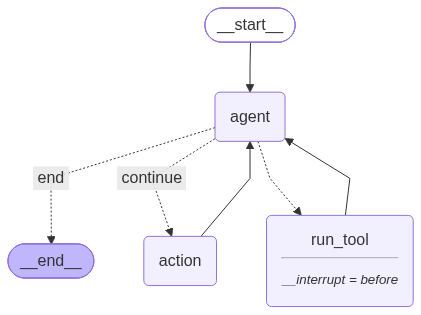

In [39]:
from IPython.display import Image, display

# 生成可视化图像结构
display_graph(graph)


&emsp;&emsp;完整的`Agent`结构编译完成后，我们现在可以与该系统进行用户交互，进行功能的测试。首先进行常规的天气信息咨询：

In [40]:
config = {"configurable": {"thread_id": "100"}}

for chunk in graph.stream({"messages": "北京的天气怎么样？并把数据插入数据库中"}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

北京的天气怎么样？并把数据插入数据库中
================================== Ai Message ==================================

I'll help you check the weather in Beijing and insert the data into the database. Let me start by querying the current weather for Beijing.
Tool Calls:
  get_weather (call_00_A1A5WmGxc9vueVf1DZ2w7135)
 Call ID: call_00_A1A5WmGxc9vueVf1DZ2w7135
  Args:
    location: Beijing
================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 116.3883, "lat": 39.9289}, "weather": [{"id": 1036, "main": "Unknown", "description": "烟霾", "icon": "//cdn.weatherapi.com/weather/64x64/night/149.png"}], "main": {"temp": 24.4, "feels_like": 26.5, "temp_min": 24.4, "temp_max": 24.4, "pressure": 1008.0, "humidity": 67}, "visibility": 7800, "wind": {"speed": 1.0, "deg": 93}, "clouds": {"all": 3}, "dt": 1786424400, "timezone": null, "id": 3993011639, "name": "Beijing", "cod

&emsp;&emsp;在这个过程中，依次执行了`query_weather_from_db`、`get_weather` 工具用来获取当前的天气信息，并且将查询到的数据实时的插入到了数据库中，我们可以进行数据验证：

&emsp;&emsp;继续加大问题的难度，如下所示：

In [41]:
config = {"configurable": {"thread_id": "100"}}

for chunk in graph.stream({"messages": "帮我同时查一下上海、杭州的天气，比较哪个城市更适合现在出游。并且把数据插入MySQL数据库"}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

帮我同时查一下上海、杭州的天气，比较哪个城市更适合现在出游。并且把数据插入MySQL数据库
================================== Ai Message ==================================

我来同时查询上海和杭州的天气，然后进行比较并插入数据库。
Tool Calls:
  get_weather (call_00_qQpvj7pRdBSbWVwemIli8134)
 Call ID: call_00_qQpvj7pRdBSbWVwemIli8134
  Args:
    location: Shanghai
  get_weather (call_01_4nLOv4YZhcdznHyiXPuW5063)
 Call ID: call_01_4nLOv4YZhcdznHyiXPuW5063
  Args:
    location: Hangzhou
================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 120.1689, "lat": 30.2553}, "weather": [{"id": 1240, "main": "Rain", "description": "小阵雨", "icon": "//cdn.weatherapi.com/weather/64x64/day/353.png"}], "main": {"temp": 25.9, "feels_like": 29.2, "temp_min": 25.9, "temp_max": 25.9, "pressure": 998.0, "humidity": 96}, "visibility": 10000, "wind": {"speed": 3.39, "deg": 96}, "clouds": {"all": 89}, "dt": 1786424400, "timezone": null, "id"

&emsp;&emsp;从输出上，该系统同样很好的完成了我们提出的所有需求。而接下来，我们触发高危操作，让其删除数据库中的一些数据，请求如下：

In [42]:
config = {"configurable": {"thread_id": "100"}}

for chunk in graph.stream({"messages": "帮我删除数据库中北京的天气数据"}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

帮我删除数据库中北京的天气数据
================================== Ai Message ==================================

我来帮您删除数据库中北京的天气数据。
Tool Calls:
  delete_weather_from_db (call_00_SYfD1HRh8BDgJvFANSBX1410)
 Call ID: call_00_SYfD1HRh8BDgJvFANSBX1410
  Args:
    city_name: Beijing


&emsp;&emsp;在这样的请求中，当`Agent`判断需要执行`delete_weather_from_db`工具时，并没有自主执行，而是进入到`breakpoint`状态，等待人工介入。我们可以通过如下方式查看到当前的图状态：

In [43]:
state = graph.get_state(config)
print(state.next)
print(state.tasks)
print(state.values)

('run_tool',)
(PregelTask(id='f2bcd7d8-c678-70f8-1599-616de26475c5', name='run_tool', path=('__pregel_pull', 'run_tool'), error=None, interrupts=(), state=None, result=None),)
{'messages': [HumanMessage(content='北京的天气怎么样？并把数据插入数据库中', additional_kwargs={}, response_metadata={}, id='20f436cb-7be0-479b-a052-0d02e885dd69'), AIMessage(content="I'll help you check the weather in Beijing and insert the data into the database. Let me start by querying the current weather for Beijing.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 1076, 'total_tokens': 1149, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 1076}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '4da737e4-dfbf-4fa7-a5d7-aea8e496eded', 'finish_reason': 'tool_calls

&emsp;&emsp;首先还是同样，如果允许删除操作，仍然在`input`参数中填写`None`，将上述全部状态信息传递到图中使其恢复中断的执行，如下所示：

In [44]:
for chunk in graph.stream(None, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================== Ai Message ==================================

我来帮您删除数据库中北京的天气数据。
Tool Calls:
  delete_weather_from_db (call_00_SYfD1HRh8BDgJvFANSBX1410)
 Call ID: call_00_SYfD1HRh8BDgJvFANSBX1410
  Args:
    city_name: Beijing
================================= Tool Message =================================
Name: delete_weather_from_db

{'messages': ["城市 'Beijing' 的天气信息已成功删除。"]}
================================== Ai Message ==================================

✅ 数据库中北京的天气数据已成功删除。

如果您需要查询确认删除结果，或者需要处理其他城市的天气数据，随时告诉我！


&emsp;&emsp;此时再查看数据库，`beijing`的天气数据是已经被正确删除了。

&emsp;&emsp;接下来，我们就可以按照这种思路，去构建完全自动化的具有人工介入的自主循环代理工作流。这个过程的关键是：**如何去处理执行外部工具或者不执行外部工具的操作逻辑。**解决的思路是：当从用户那里获得自然语言反馈是不允许执行高危操作的时候，我们可以将这些反馈作为工具调用的模拟数据进行插入。代码如下所示：

In [107]:
config = {"configurable": {"thread_id": "101"}}

for chunk in graph.stream({"messages": "帮我删除数据库中杭州的天气数据"}, config, stream_mode="values"):
    state = graph.get_state(config)

    # print(state.next)
    # print(state.tasks)

    # 检查是否有任务，如果没有则结束循环
    if not state.tasks:
        # print("所有任务都已完成。")
        chunk["messages"][-1].pretty_print()
        break
    
    if state.tasks[0].name == 'run_tool':
        while True:
            user_input = input("是否允许执行删除操作？请输入'是'或'否'：")
            if user_input in ["是", "否"]:
                break
            else:
                print("输入错误，请输入'是'或'否'。")
            
        if user_input == "是":
            graph.update_state(config=config, values=chunk)
            for event in graph.stream(None, config, stream_mode="values"):
                event["messages"][-1].pretty_print()
        elif user_input == "否":
            state = graph.get_state(config)
            tool_call_id = state.values["messages"][-1].tool_calls[0]["id"]
            print(tool_call_id)

            #我们现在需要构造一个替换工具调用。把参数改为“xxsd”，请注意，我们可以更改任意数量的参数或工具名称-它必须是一个有效的
            new_message = {
                "role": "tool",
                # 这是得到的用户不允许操作的反馈
                "content": "管理员不允许执行该操作！",
                "name": "delete_weather_from_db",
                "tool_call_id": tool_call_id,
            }
            graph.update_state(config, {"messages": [new_message]}, as_node="run_tool",)
            for event in graph.stream(None, config, stream_mode="values"):
                event["messages"][-1].pretty_print()

是否允许执行删除操作？请输入'是'或'否'： 否


call_Wg2nS6o6OVHgpTo55xeZmTHB
================================= Tool Message =================================
Name: delete_weather_from_db

管理员不允许执行该操作！
================================== Ai Message ==================================

抱歉，管理员不允许执行删除数据库中的天气数据。如果您还有其他需要，欢迎告诉我！


&emsp;&emsp;注意，这里的关键是：需要更新 `state`。对于模拟的工具数据来说，需要传递一条消息，该消息的 ID 与要响应的工具调用ID相同。接下来我们就可以基于这种逻辑来构建具有人机交互的多轮对话代理：

In [45]:
def run_multi_round_dialogue(graph, config):
  
    while True:  # 开始多轮循环
        # 询问用户输入操作，允许退出
        user_input = input("请输入您的问题（例如：'帮我查询上海的天气数据'），输入'退出'结束对话：")
        
        # 检查是否退出对话
        if user_input.lower() == '退出':
            print("对话已结束。")
            break

        # 启动对话，根据用户的输入进行处理
        for chunk in graph.stream({"messages": user_input}, config, stream_mode="values"):
            state = graph.get_state(config)

            # 如果没有任务则结束这一轮循环
            if not state.tasks:
                if "messages" in chunk and len(chunk["messages"]) > 0:
                    print("人工智能助理：", chunk["messages"][-1].content)
                break
            
            # 处理动态断点的任务
            if state.tasks[0].name == 'run_tool':
                user_approval = None
                while True:
                    user_approval = input("是否允许执行删除操作？请输入'是'或'否'：")
                    if user_approval in ["是", "否"]:
                        break
                    else:
                        print("输入错误，请输入'是'或'否'。")
                    
                if user_approval == "是":
                    graph.update_state(config=config, values=chunk)
                    for event in graph.stream(None, config, stream_mode="values"):
                        if "messages" in event and len(event["messages"]) > 0:
                            print("人工智能助理：",  event["messages"][-1].content)
                            # event["messages"][-1].pretty_print()
                elif user_approval == "否":
                    state = graph.get_state(config)
                    tool_call_id = state.values["messages"][-1].tool_calls[0]["id"]

                    # 构造一个反馈消息来停止操作
                    new_message = {
                        "role": "tool",
                        "content": "管理员不允许执行该操作！",
                        "name": "delete_weather_from_db",
                        "tool_call_id": tool_call_id,
                    }
                    graph.update_state(config, {"messages": [new_message]}, as_node="run_tool")
                    for event in graph.stream(None, config, stream_mode="values"):
                        if "messages" in event and len(event["messages"]) > 0:
                            print("人工智能助理：",  event["messages"][-1].content)
                            #event["messages"][-1].pretty_print()

In [46]:
config = {"configurable": {"thread_id": "102"}}

# 使用该函数启动对话
run_multi_round_dialogue(graph, config)

请输入您的问题（例如：'帮我查询上海的天气数据'），输入'退出'结束对话： 查询上海的天气


人工智能助理： I've retrieved the current weather for Shanghai. Let me present the results:

## 上海当前天气 🌧️

| 项目 | 数据 |
|------|------|
| **天气状况** | 小阵雨 (Rain) |
| **温度** | 25.9°C |
| **体感温度** | 28.2°C |
| **最低/最高温度** | 25.9°C / 25.9°C |
| **气压** | 1000 hPa |
| **湿度** | 95% |
| **能见度** | 10,000 米 |
| **风速** | 5.89 m/s（东南偏东方向，114°）|
| **云量** | 100% |

**总结：** 上海目前正在下小阵雨，气温约 26°C，湿度较高（95%），体感温度达到 28.2°C，天气较为闷热潮湿。出门请记得携带雨具哦！☔

需要我将这些天气数据保存到数据库中吗？


请输入您的问题（例如：'帮我查询上海的天气数据'），输入'退出'结束对话： 查询广州的天气然后插入数据库


人工智能助理： 广州的天气数据已成功查询并插入数据库！✅

## 广州当前天气 🌫️

| 项目 | 数据 |
|------|------|
| **天气状况** | 烟霾 |
| **温度** | 34.0°C |
| **体感温度** | 37.9°C |
| **最低/最高温度** | 34.0°C / 34.0°C |
| **气压** | 999 hPa |
| **湿度** | 49% |
| **能见度** | 4,200 米 |
| **风速** | 1.0 m/s（南偏西方向，185°）|
| **云量** | 21% |

**总结：** 广州目前有烟霾天气，气温高达 34°C，体感温度达到 37.9°C，天气炎热，能见度较低（4,200米）。请注意防暑降温，并减少户外活动。🥵

天气数据已成功存储至 MySQL 数据库。如需查询或删除该数据，请随时告诉我！


请输入您的问题（例如：'帮我查询上海的天气数据'），输入'退出'结束对话： 从数据库中查询上海的天气


...

人工智能助理： 美国纽约的天气数据已成功查询并插入数据库！✅

## 纽约当前天气 ⛅

| 项目 | 数据 |
|------|------|
| **天气状况** | 局部多云 (Clouds) |
| **温度** | 26.3°C |
| **体感温度** | 28.8°C |
| **最低/最高温度** | 26.3°C / 26.3°C |
| **气压** | 1014 hPa |
| **湿度** | 74% |
| **能见度** | 16,100 米 |
| **风速** | 3.5 m/s（西北方向，318°）|
| **云量** | 25% |

**总结：** 纽约目前为局部多云天气，气温约 26°C，体感温度 28.8°C，天气温暖舒适，能见度良好。☀️

天气数据已成功存储至 MySQL 数据库。目前数据库中已有 **广州、上海、东京、纽约** 四个城市的天气数据。如需其他操作，请随时告诉我！


请输入您的问题（例如：'帮我查询上海的天气数据'），输入'退出'结束对话： 删除数据库中纽约的天气
是否允许执行删除操作？请输入'是'或'否'： 是


人工智能助理： I'll delete the weather data for New York from the database.
人工智能助理： {'messages': ["城市 'New York' 的天气信息已成功删除。"]}
人工智能助理： 纽约的天气数据已成功从数据库中删除！✅

目前数据库中剩余的城市天气数据为：
1. **广州 (Guangzhou)** - 烟霾，34.0°C
2. **上海 (Shanghai)** - 小阵雨，27.1°C
3. **东京 (Tokyo)** - 薄雾，23.8°C

如需其他操作，请随时告诉我！


请输入您的问题（例如：'帮我查询上海的天气数据'），输入'退出'结束对话： 退出


对话已结束。


&emsp;&emsp;如上代码中实现的`Agent`系统中，人机协同 （HIL） 功能为用户参与和决策提供了强大的机制。通过合并断点和验证消息，可以确保人工的决策可以无缝集成到代理的工作流程中，通过允许实时干预和批准工具选择来增强代理的操作流程，增强整个`AI`系统的可信性和健壮性。而这样的一个实现思路，其实也只是在我们已经介绍的`checkpointer`知识点上，通过合理化的应用技巧来快速实现更具现实落地应用价值的`Agent`形态。 

&emsp;&emsp;截至到本节课，我们已经完全结束了`LangGraph`框架中所有重要的底层概念和组件的学习。大家在后续的独立开发过程中，只有理解各个组件的原理和实现思路才能支撑大家根据不同的需求场景去定制化自己所构建的`Agent`的个性化功能，这就是`LangGraph`能被广大开发者喜爱和能成为生产级智能应用底层开发框架的优势所在。除此之外，大家比较关注的`Mulit-Agent`代理架构，当我们完全掌握了课程中`Single-Agent`的全部内容后，再去学习和使用多代理完全是游刃有余的。下一节课，我们就将围绕`LangGraph`的`Multi-Agent`展开详细的学习和实践。